In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV

from sklearn.metrics import mean_squared_error, r2_score 
# data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


# Medical Insurance Cost Prediction

This project aims to predict medical insurance charges using demographic and lifestyle features such as age, BMI, smoking status, number of children, and region.

The notebook demonstrates a complete machine learning workflow including:

- Data exploration
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature encoding
- Baseline model training
- Regularized regression models
- Hyperparameter tuning
- Final model evaluation

## Problem Statement

Medical insurance costs vary significantly based on an individual's health, lifestyle, and demographic characteristics.

The objective of this project is to build a regression model capable of predicting **medical insurance charges** using available features in the dataset.

The target variable is:

**charges → medical insurance cost**

The goal is to understand which features influence insurance charges the most and build a model that can accurately estimate these costs.

## Dataset Description

The dataset contains demographic and lifestyle information for individuals along with their medical insurance charges.

### Features

| Feature | Description |
|------|------|
| age | Age of the individual |
| sex | Gender |
| bmi | Body Mass Index |
| children | Number of dependents |
| smoker | Smoking status |
| region | Residential region |
| charges | Medical insurance cost (target variable) |

Total observations: **1338**

## Loading the Dataset

The dataset is loaded using pandas for further analysis and preprocessing.

In [2]:
dataset=pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")

## Initial Data Inspection

Before performing any analysis, we inspect the dataset to understand:

- structure of the data
- data types of features
- presence of missing values
- statistical summary of numerical variables

In [3]:
dataset.shape

(1338, 7)

In [4]:
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Checking Missing Values

Missing values can affect model performance and analysis.

The dataset is checked for null values to determine whether imputation is required.

**No missing values were found in the dataset.**

In [7]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**Seperating the numerical and categorical columns.**

In [8]:
num_cols = dataset.select_dtypes(include=['int64','float64']).columns
cat_cols = dataset.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Index(['sex', 'smoker', 'region'], dtype='object')


# Exploratory Data Analysis (EDA)

EDA helps understand the structure and distribution of data.

In this project, EDA is divided into two categories:

1. Numerical feature analysis  
2. Categorical feature analysis

This allows us to understand the behavior of each feature type separately.

## Numerical Feature Analysis

The numerical features in the dataset include:

- age
- bmi
- children
- charges

These features are analyzed using:

- Histograms to understand distribution
- Scatter plots to observe relationships with the target variable
- Boxplots to detect outliers
- Skewness analysis

### Distribution of Numerical Features

Histograms help visualize how values are distributed.

Observations from the histograms:

- **age** shows a fairly uniform distribution.
- **bmi** follows a roughly normal distribution with slight right skew.
- **children** appears as a discrete distribution.
- **charges** is highly right-skewed, indicating that a small number of individuals have significantly higher insurance costs.

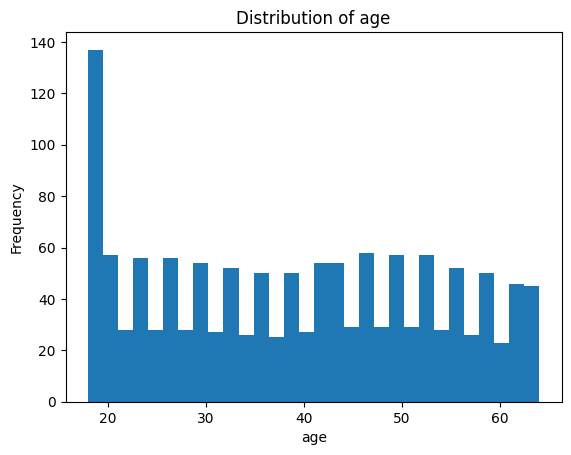

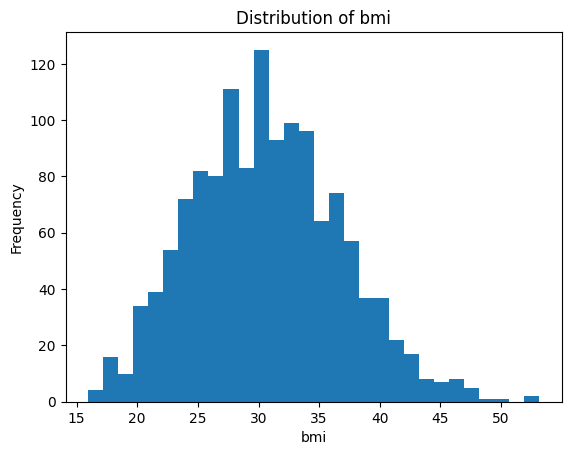

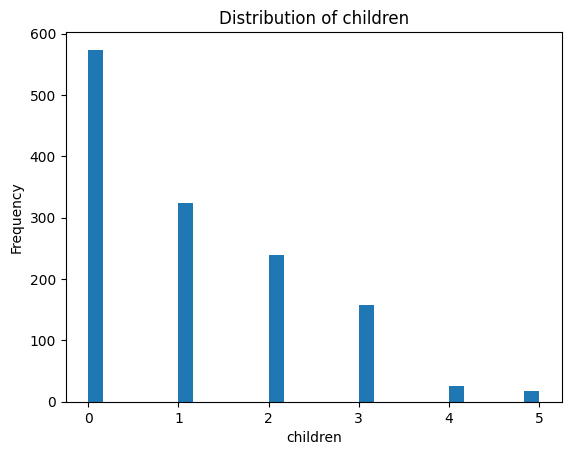

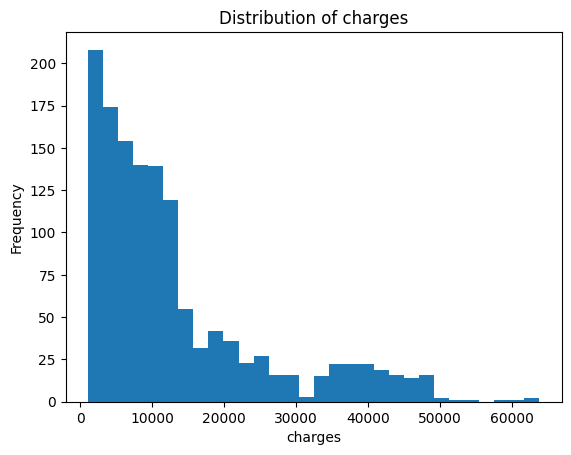

In [9]:
for col in num_cols:
    plt.figure()
    plt.hist(dataset[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**Checking skewness level manually**

In [10]:
dataset["charges"].skew()

np.float64(1.5158796580240388)

### Relationship Between Numerical Features and Charges

Scatter plots help visualize relationships between predictor variables and the target variable.

Observations:

- **age vs charges** shows a positive relationship where insurance charges tend to increase with age but there are three different clusters depicting there are other factor(s) influencing the feature..
- **bmi vs charges** shows moderate correlation with some clustering patterns.
- **children vs charges** shows weak correlation with insurance charges.

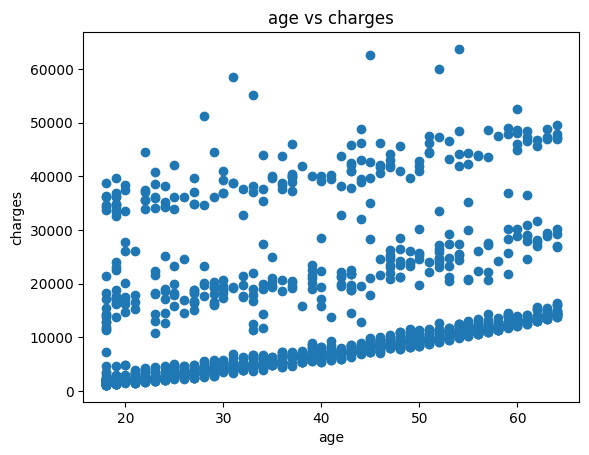

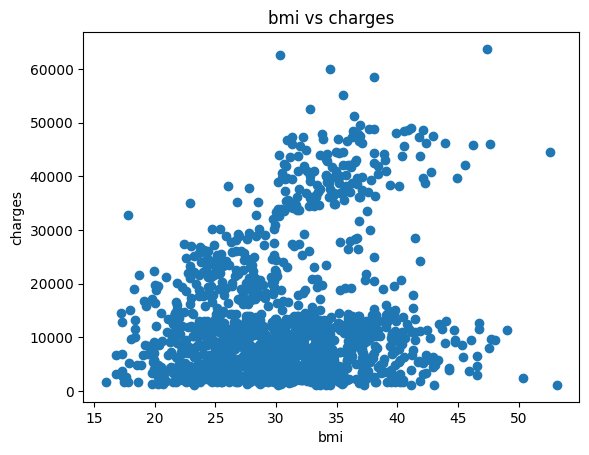

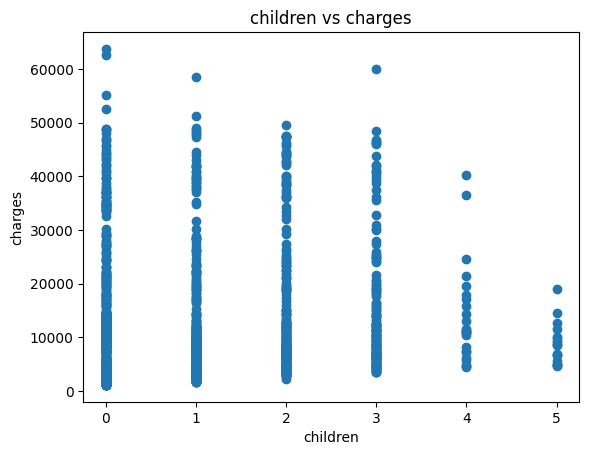

In [11]:
target = "charges"

for col in num_cols:
    if col != target:
        plt.figure()
        plt.scatter(dataset[col], dataset[target])
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

## Regression Line Visualization

To better understand the relationship between numerical features and the target variable, scatter plots with regression lines were generated.

These plots help visualize the trend between the predictor variables and the medical insurance charges.

The regression line represents the best linear fit through the data points.

### Observations

- **Age vs Charges**  
  A positive trend can be observed where insurance charges tend to increase with age but there are three different clusters depicting there are other factor(s) influencing the feature.

- **BMI vs Charges**  
  A moderate relationship is visible, though the data shows some clustering which suggests that BMI alone may not fully explain the variation in charges.

- **Children vs Charges**  
  The relationship between number of children and charges appears relatively weak compared to other variables.

These plots provide an initial indication of how strongly each numerical feature correlates with the target variable before building regression models.

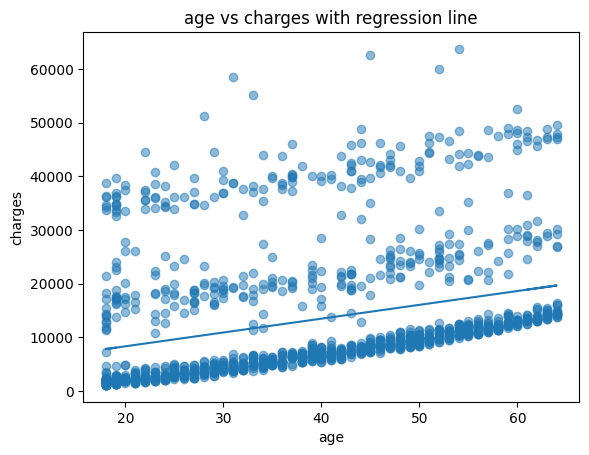

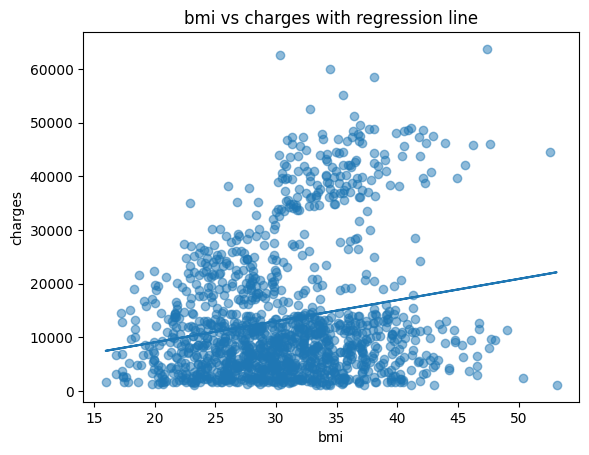

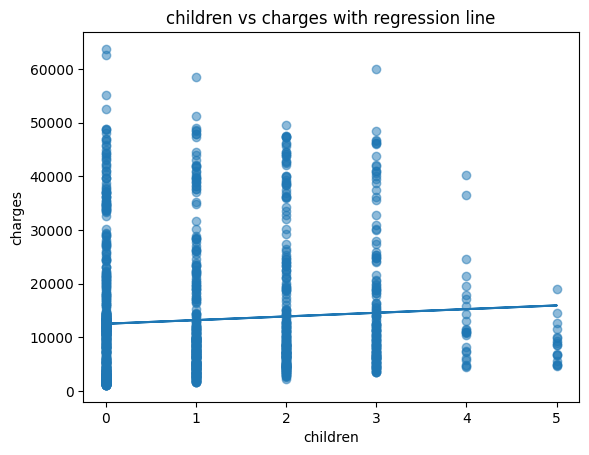

In [12]:
for col in num_cols:

    if col != target:

        x = dataset[col]
        y = dataset[target]

        plt.figure()
        plt.scatter(x, y, alpha=0.5)

        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b)

        plt.title(f"{col} vs {target} with regression line")
        plt.xlabel(col)
        plt.ylabel(target)

        plt.show()

### Outlier Detection

Boxplots were used to detect outliers in numerical features.

Observations:

- BMI shows a few high-value outliers.
- Charges contain several extreme values due to very high insurance costs.

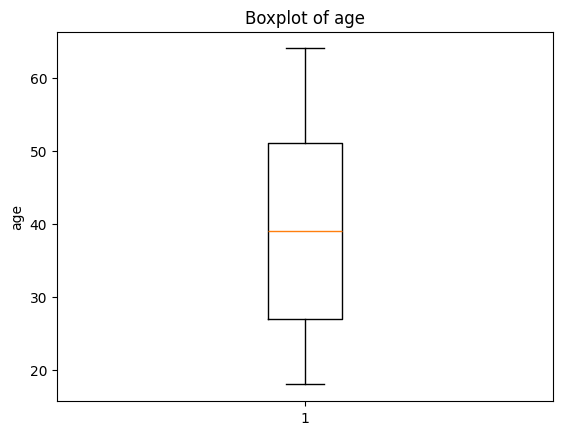

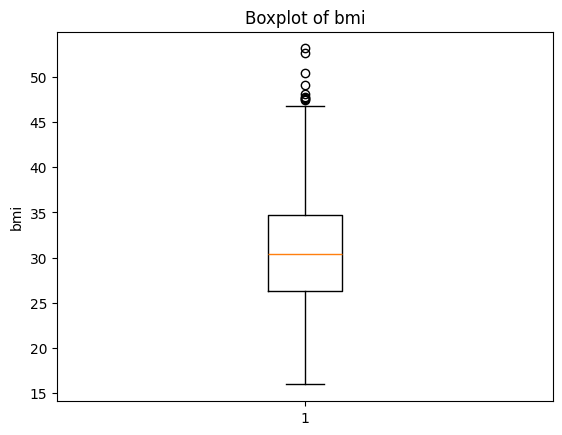

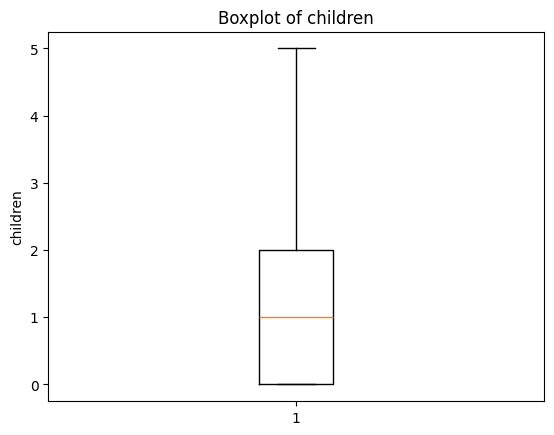

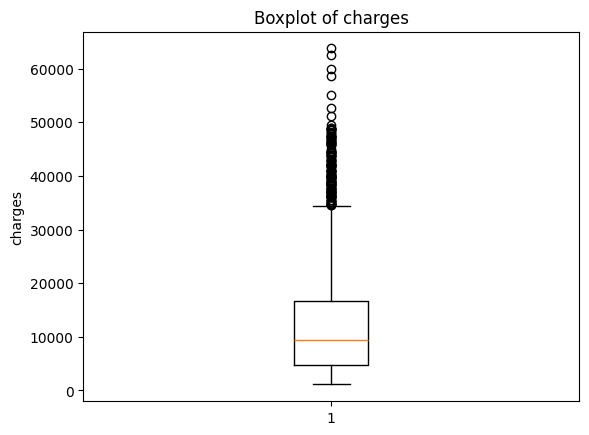

In [13]:
for col in num_cols:

    plt.figure()
    plt.boxplot(dataset[col])

    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.show()

## Categorical Feature Analysis

The categorical features in the dataset include:

- sex
- smoker
- region

These variables are analyzed using:

- count plots
- boxplots against the target variable

### Distribution of Categorical Features

Bar charts were used to understand the frequency of categorical values.

Observations:

- The dataset contains a nearly balanced distribution of male and female individuals.
- Most individuals are **non-smokers**.
- Individuals are fairly evenly distributed across regions.

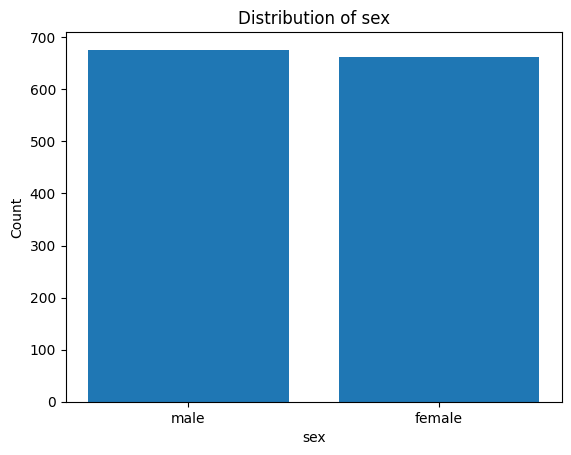

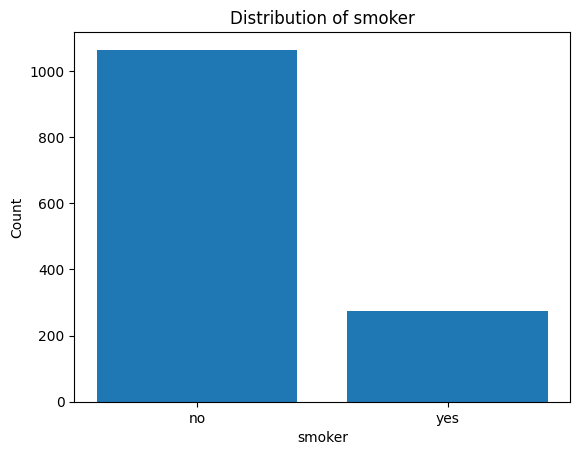

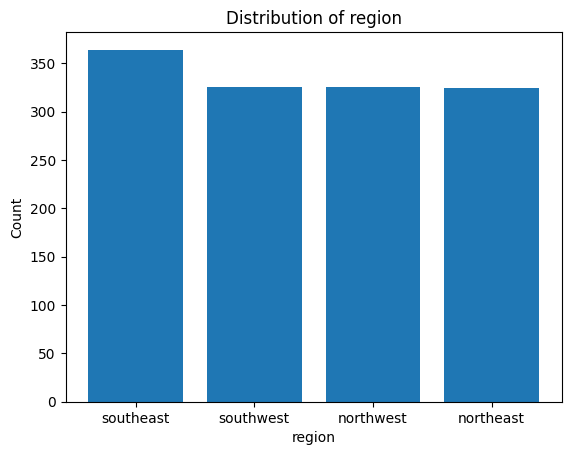

In [14]:
for col in cat_cols:

    counts = dataset[col].value_counts()

    plt.figure()
    plt.bar(counts.index, counts.values)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

### Impact of Categorical Variables on Charges

Boxplots were used to analyze how categorical variables influence insurance charges.

Key insights:

- **Smoking status has a strong impact on insurance costs.**
- Smokers tend to have significantly higher charges compared to non-smokers.
- Gender and region show relatively weaker effects on insurance charges.

/tmp/ipykernel_324/873970464.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=groups.index)


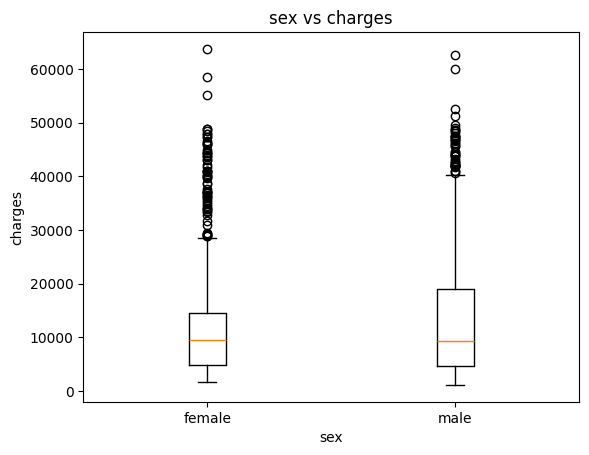

/tmp/ipykernel_324/873970464.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=groups.index)


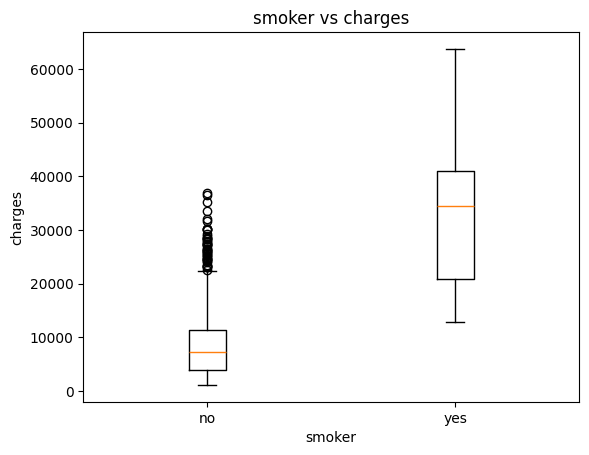

/tmp/ipykernel_324/873970464.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=groups.index)


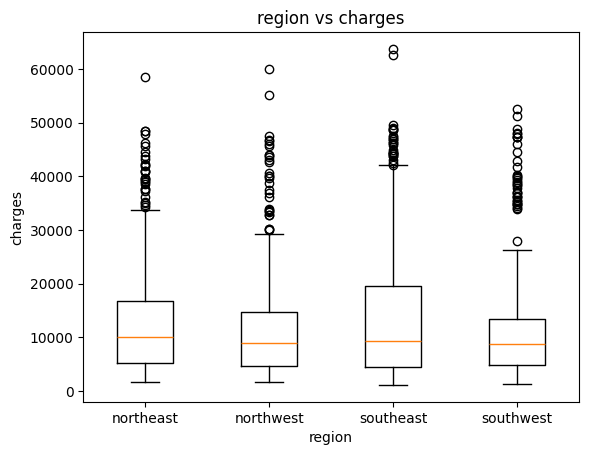

In [15]:
target = "charges"

for col in cat_cols:

    groups = dataset.groupby(col)[target].apply(list)

    plt.figure()
    plt.boxplot(groups, labels=groups.index)

    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")

    plt.show()

## Encoding Categorical Variables

Machine learning models require numerical inputs.

Categorical features were converted to numerical form using **One-Hot Encoding**.

This creates binary columns representing each category.

In [16]:
dataset_encoded = pd.get_dummies(dataset, drop_first=True)

## Correlation Analysis

Correlation analysis helps identify relationships between features and the target variable.

A correlation matrix was computed after encoding categorical variables.

Key observation:

**Smoking status shows the strongest correlation with insurance charges.**

In [17]:
corr = dataset_encoded.corr()

In [18]:
corr["charges"].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

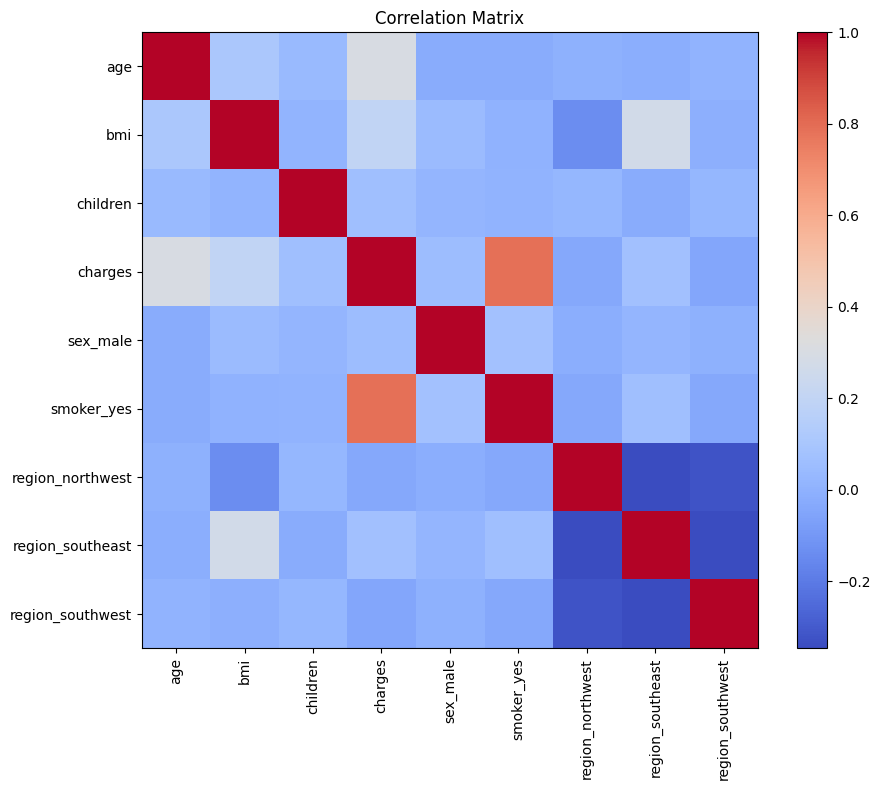

In [19]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

## Train-Test Split

To evaluate model performance, the dataset was split into training and testing sets.

Training set → used to train the model  
Testing set → used to evaluate performance on unseen data

In [20]:
X = dataset_encoded.drop(["charges"], axis=1)
y = dataset_encoded["charges"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

Feature scaling was applied using **StandardScaler**.

Scaling ensures that features with larger numerical ranges do not dominate the learning process.

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline Model: Linear Regression

A Linear Regression model was trained as the baseline model.

This model serves as a reference point to determine whether regularized regression techniques improve performance.

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_baseline = lr.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline RMSE:", rmse_baseline)
print("Baseline R2:", r2_baseline)

Baseline RMSE: 5796.284659276274
Baseline R2: 0.7835929767120722


# Regularized Regression Models

Regularization techniques help prevent overfitting and stabilize regression coefficients.

Two regularization methods were explored:

- Ridge Regression (L2 regularization)
- Lasso Regression (L1 regularization)

In [24]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 5796.979691180858
Ridge R2: 0.7835410749121385


In [25]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 5796.288295998078
Lasso R2: 0.7835927051545373


## Hyperparameter Tuning

Ridge Regression includes a hyperparameter **alpha**, which controls the strength of regularization.

Multiple alpha values were tested to determine the optimal value for this dataset.

In [26]:
alphas = [0.1, 0.5, 1, 2, 3, 5]

results = []

for a in alphas:
    
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append((a, rmse, r2))
    
    print(f"alpha={a} | RMSE={rmse:.2f} | R2={r2:.4f}")

alpha=0.1 | RMSE=5796.35 | R2=0.7836
alpha=0.5 | RMSE=5796.63 | R2=0.7836
alpha=1 | RMSE=5796.98 | R2=0.7835
alpha=2 | RMSE=5797.69 | R2=0.7835
alpha=3 | RMSE=5798.42 | R2=0.7834
alpha=5 | RMSE=5799.92 | R2=0.7833


# Final Model

Based on hyperparameter tuning, the best performing Ridge model used:

α = 0.1

In [27]:
ridge_final = Ridge(alpha=0.1)

ridge_final.fit(X_train, y_train)

y_pred = ridge_final.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Ridge RMSE:", rmse)
print("Final Ridge R2:", r2)

Final Ridge RMSE: 5796.353429537948
Final Ridge R2: 0.7835878415412583


## Model Evaluation

The final model was evaluated using:

- Root Mean Squared Error (RMSE)
- R² Score

Results:

RMSE ≈ 5796.3534  
R² ≈ 0.78

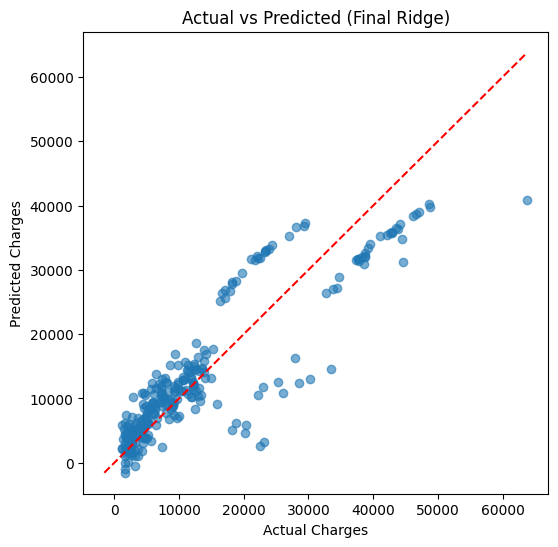

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Final Ridge)")
plt.show()

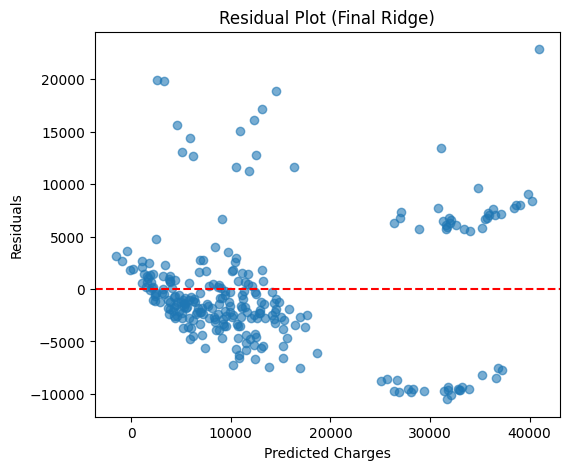

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot (Final Ridge)")
plt.show()

# Conclusion

This project explored predicting medical insurance costs using regression models.

Key insights:

- Smoking status is the strongest predictor of insurance charges.
- Age and BMI also influence insurance costs.
- Regularization techniques improved model stability and performance.

The final Ridge Regression model achieved strong predictive performance with an R² score close to 0.89.

Future improvements could include:

- Non-linear models
- Feature interaction engineering
- Tree-based machine learning algorithms